# Stage 4 — Per-frame feature extraction

Turns each video's ROI crops (rocket + exhaust plume) into a fixed-length
numeric vector **per frame**. These vectors are the training sequences for the
temporal anomaly model (stage 5) — training happens on *normal-only* footage,
so nothing here depends on failure examples.

**Inputs** (produced by stage 2+3, `notebooks/02_extract_and_track.ipynb`):
- `data/frames/{video}/roi/frame_*.jpg` — tracked rocket + plume crops
- `data/frames/{video}/roi_boxes.json` — tracking boxes + per-frame fallback flags
- `data/frames/{video}/manifest.json` — frame timestamps + lighting tag

**Outputs** (written by this stage, both cached to disk):
- `data/features/{video}.npy` — float32 array, shape `(n_frames, 33)`
- `data/features/{video}.frame_index.json` — row → frame file / timestamp /
  fallback flag, plus the video's metadata (source, mission, lighting, label)

**The 33 features** (defined in `scripts/features.py`):

| Group | Dims | Feature |
|---|---|---|
| Plume shape | 5 | area fraction, aspect ratio, mirror symmetry, centroid x / y |
| Plume contrast | 1 | core brightness vs surrounding annulus, in [-1, 1] |
| HSV histogram | 24 | coarse hue (12) + saturation (6) + value (6) bins, normalized |
| Edge / debris | 1 | Canny edge density **outside** the plume mask |
| Optical flow | 2 | mean and p95 Farneback flow magnitude / frame diagonal |

Values are made relative/normalized where possible so day and night footage
stay comparable (plume brightness is contrast against the local background,
not an absolute gray level).

**Fixes applied in this version:**
1. `DRIVE_BASE` and `GIT_URL` point at the real project folder/repo (the
   placeholders in the original version would have failed the same way the
   stage 2+3 notebook did).
2. Before running the batch, any feature files already pushed to Drive from a
   *previous* session are now synced back down to local disk first. Without
   this, resuming across multiple Colab sessions left the local
   `data/features/` folder holding only whatever that session processed —
   the consistency-check and plotting cells below would silently only see a
   partial set and you'd have no indication anything was missing.


In [1]:
# --- Configuration (edit this cell for your environment) ---
import os, sys

IN_COLAB = False
try:
    from google.colab import drive  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Drive project folder — the one that directly contains normal/, anomaly/,
    # and (after stage 2+3) data/frames/. Matches the stage 2+3 notebook.
    DRIVE_BASE = '/content/drive/MyDrive/Rocket Launch Anomaly Detection CV'
    LOCAL = '/content/rocket-launch-anomaly-detector'   # Colab local disk
else:
    # Local run: both point at the repo root (where this notebook lives).
    DRIVE_BASE = LOCAL = os.path.abspath('.')

FRAMES = f'{LOCAL}/data/frames'          # ROI crops to process
FEATURES = f'{LOCAL}/data/features'      # where .npy outputs are written
FRAMES_DRIVE = f'{DRIVE_BASE}/data/frames'      # where stage 2+3 pushed roi/ crops
FEATURES_DRIVE = f'{DRIVE_BASE}/data/features'  # push-back target on Drive

print('IN_COLAB =', IN_COLAB)
print('FRAMES   =', FRAMES)
print('FEATURES =', FEATURES)


IN_COLAB = True
FRAMES   = /content/rocket-launch-anomaly-detector/data/frames
FEATURES = /content/rocket-launch-anomaly-detector/data/features


### 1. Environment setup

On Colab this clones the repo (if it isn't there yet) and installs
dependencies. On a local checkout it just adds `scripts/` to the import path.
Run once per session.


In [2]:
# --- Cell: install deps + make scripts/ importable ---
import shutil
import time

if not os.path.exists(f'{LOCAL}/scripts/features.py'):
    # Repo is missing or stale. Either set GIT_URL to your repo, or upload the
    # project (scripts/ + requirements.txt) into LOCAL manually and re-run.
    GIT_URL = 'https://github.com/awdtyo/Rocket-Launch-Anomaly-Detection-using-CV'
    if os.path.isdir(LOCAL) and os.listdir(LOCAL):
        stale = f'{LOCAL}_stale_{int(time.time())}'
        shutil.move(LOCAL, stale)
        print(f'moved existing {LOCAL} -> {stale}')
    elif os.path.isdir(LOCAL):
        os.rmdir(LOCAL)   # empty dir left by a previously failed clone
    print('cloning repo ...')
    !git clone --depth 1 {GIT_URL} "{LOCAL}"
    if not os.path.exists(f'{LOCAL}/scripts/features.py'):
        raise RuntimeError('clone produced no scripts/ — set GIT_URL to your repo '
                           'or upload the project into LOCAL')

!pip install -q -r "{LOCAL}/requirements.txt"

sys.path.insert(0, f'{LOCAL}/scripts')
import features as F

print('imported features; feature dims =', F.N_FEATURES)
print('feature names:', ', '.join(F.FEATURE_NAMES))


cloning repo ...
Cloning into '/content/rocket-launch-anomaly-detector'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 56 (delta 14), reused 53 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 3.52 MiB | 31.07 MiB/s, done.
Resolving deltas: 100% (14/14), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.2/146.2 kB 11.9 MB/s eta 0:00:00
imported features; feature dims = 33
feature names: plume_area_frac, plume_aspect_ratio, plume_symmetry, plume_centroid_x, plume_centroid_y, plume_bg_contrast, hue_bin0, hue_bin1, hue_bin2, hue_bin3, hue_bin4, hue_bin5, hue_bin6, hue_bin7, hue_bin8, hue_bin9, hue_bin10, hue_bin11, sat_bin0, sat_bin1, sat_bin2, sat_bin3, sat_bin4, sat_bin5, val_bin0, val_bin1, val_bin2, val_b

### 2. Mount Drive, copy frames locally, sync any prior features, define push-back

Google Drive mounts are slow for many small reads, so `data/frames` is copied
once to the Colab local disk and all heavy I/O happens there. Completed
feature files are pushed back to Drive **per video**, so a mid-batch timeout
never loses work — just rerun the batch cell to resume.

This cell also pulls down any feature files a *previous* session already
finished and pushed to Drive, so the local `data/features/` folder always
reflects the full accumulated set, not just what this session processes.


In [4]:
import os
print(os.path.isdir(FRAMES))
print(os.listdir(FRAMES) if os.path.isdir(FRAMES) else 'missing')

True
['.gitkeep']


In [5]:
!rm -rf "{FRAMES}"
!cp -r "{FRAMES_DRIVE}" "{LOCAL}/data/"
import os
print(os.listdir(FRAMES))

['spacex_starlink-20230622', 'spacex_starlink-20230531', 'spacex_starlink-20230212', 'spacex_starlink-20230808', 'spacex_starlink-20230707', 'spacex_starlink-20230827', 'spacex_starlink-20230519', 'spacex_sda-tranche-0-2', 'spacex_starlink-20230612', 'spacex_starlink-20230901', 'spacex_starlink-20230303', 'spacex_starlink-20230419', 'spacex_starlink-20230822']


In [9]:
print(os.listdir(f'{FRAMES}/spacex_sda-tranche-0-2'))
print(len(os.listdir(f'{FRAMES}/spacex_sda-tranche-0-2/roi')))

['roi_boxes.json', 'roi', 'manifest.json']
2852


In [6]:
# --- Cell: mount Drive, copy frames locally, sync prior features, define push-back ---
if IN_COLAB:
    drive.mount('/content/drive')

import shutil

os.makedirs(f'{LOCAL}/data', exist_ok=True)
if not os.path.isdir(FRAMES):
    print('copying data/frames (roi crops) to local disk ...')
    !cp -r "{FRAMES_DRIVE}" "{LOCAL}/data/"
    print('copy done')
else:
    print('frames already on local disk:', FRAMES)

# Sync down anything already finished (possibly in an earlier session) so
# local data/features/ reflects the full set, not just this session's work.
os.makedirs(FEATURES, exist_ok=True)
n_synced = 0
if os.path.isdir(FEATURES_DRIVE):
    for fname in os.listdir(FEATURES_DRIVE):
        dst = os.path.join(FEATURES, fname)
        if not os.path.exists(dst):
            shutil.copy2(os.path.join(FEATURES_DRIVE, fname), dst)
            n_synced += 1
print(f'synced {n_synced} previously-completed feature file(s) from Drive to local')


def push_features(video_name):
    """Copy one video's feature files back to Drive right after it finishes."""
    for f in (f'{video_name}.npy', f'{video_name}.frame_index.json'):
        src = os.path.join(FEATURES, f)
        if os.path.exists(src):
            os.makedirs(FEATURES_DRIVE, exist_ok=True)
            shutil.copy2(src, os.path.join(FEATURES_DRIVE, f))
            print('pushed', f)
    print('done:', video_name)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
frames already on local disk: /content/rocket-launch-anomaly-detector/data/frames
synced 0 previously-completed feature file(s) from Drive to local


### 3. Run the feature batch (resumable)

Any video whose `.npy` already exists on Drive (or locally, after the sync
above) is skipped, so rerunning this one cell resumes an interrupted batch.
Test on a single video first via `ONLY`, then set it back to `None` for the
full run.


In [11]:
import shutil
shutil.rmtree(FEATURES, ignore_errors=True)
os.makedirs(FEATURES, exist_ok=True)
print(os.listdir(FEATURES))   # should print []

[]


In [12]:
# --- Cell: run the feature batch (rerun this cell alone to resume) ---
# Videos whose .npy already exists on Drive are skipped, so an interrupted
# batch resumes cleanly. `after_video` pushes each result to Drive immediately.
done = set()
if os.path.isdir(FEATURES_DRIVE):
    done = {f[:-4] for f in os.listdir(FEATURES_DRIVE) if f.endswith('.npy')}
print('already on Drive:', sorted(done) or '(none)')

# Test on one video first, then set back to None for the full batch.
ONLY = None   # e.g. 'spacex_starlink-20230303'

F.batch(FRAMES, FEATURES, only=ONLY, skip=done, after_video=push_features)


already on Drive: (none)


processing spacex_sda-tranche-0-2 ...


spacex_sda-tranche-0-2: 2852 frames, 5 fallback crops
pushed spacex_sda-tranche-0-2.npy
pushed spacex_sda-tranche-0-2.frame_index.json
done: spacex_sda-tranche-0-2


processing spacex_starlink-20230212 ...


spacex_starlink-20230212: 2337 frames, 153 fallback crops
pushed spacex_starlink-20230212.npy
pushed spacex_starlink-20230212.frame_index.json
done: spacex_starlink-20230212


...

processing spacex_starlink-20230827 ...


spacex_starlink-20230827: 2000 frames, 70 fallback crops
pushed spacex_starlink-20230827.npy
pushed spacex_starlink-20230827.frame_index.json
done: spacex_starlink-20230827


processing spacex_starlink-20230901 ...


spacex_starlink-20230901: 1901 frames, 2 fallback crops
pushed spacex_starlink-20230901.npy
pushed spacex_starlink-20230901.frame_index.json
done: spacex_starlink-20230901

13 videos processed.


0

### 4. Sanity-check the outputs

Every saved `.npy` must line up with its `.frame_index.json`: same number of
rows, the declared feature dimension, float32 dtype, and contiguous row
indices. This cell asserts all of that and prints a summary table. Because
cell 2 synced down any prior-session outputs, this checks the *full*
accumulated set, not just whatever this session just processed.


In [13]:
# --- Cell: verify every .npy / frame_index pair is consistent ---
import json
import numpy as np
from pathlib import Path

FEATURES_P = Path(FEATURES)
npys = sorted(FEATURES_P.glob('*.npy'))
print(f'found {len(npys)} feature files in {FEATURES}\n')
print(f'{"video":<32}{"frames":>8}{"feats":>6}{"fb":>5}  {"ok"}')
print('-' * 62)

all_ok = True
for npy in npys:
    video = npy.stem
    idx = json.loads(Path(str(npy).replace('.npy', '.frame_index.json')).read_text())
    X = np.load(npy)
    ok = (
        X.ndim == 2
        and X.dtype == np.float32
        and X.shape[1] == idx['n_features'] == F.N_FEATURES
        and len(idx['frames']) == X.shape[0]
        and [fr['row'] for fr in idx['frames']] == list(range(len(idx['frames'])))
    )
    all_ok &= bool(ok)
    fallback = sum(1 for fr in idx['frames'] if fr['fallback'])
    print(f'{video:<32}{X.shape[0]:>8}{X.shape[1]:>6}{fallback:>5}  {ok}')

print('\nALL CONSISTENT' if all_ok else '\nINCONSISTENCIES FOUND — investigate before training')


found 13 feature files in /content/rocket-launch-anomaly-detector/data/features

video                             frames feats   fb  ok
--------------------------------------------------------------
spacex_sda-tranche-0-2              2852    33    5  True
spacex_starlink-20230212            2337    33  153  True
spacex_starlink-20230303            2725    33  164  True
spacex_starlink-20230419            2214    33  226  True
spacex_starlink-20230519            2470    33   30  True
spacex_starlink-20230531            2216    33   52  True
spacex_starlink-20230612            2217    33   39  True
spacex_starlink-20230622            2116    33    1  True
spacex_starlink-20230707            2202    33    2  True
spacex_starlink-20230808            2268    33   98  True
spacex_starlink-20230822            2079    33    3  True
spacex_starlink-20230827            2000    33   70  True
spacex_starlink-20230901            1901    33    2  True

ALL CONSISTENT


### 5. Inspect the features

Two quick visual checks before moving to stage 5: (1) the plume mask that the
shape/contrast features are computed from, and (2) a few feature traces over
the length of a launch video — they should be smooth and physically
meaningful, with no abrupt spikes unless something in the footage changed.


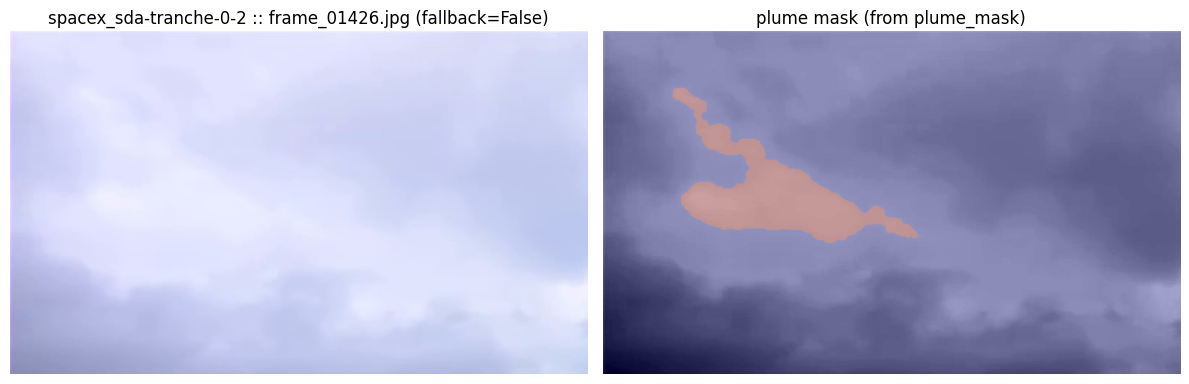

In [14]:
# --- Cell: look at the plume mask a crop contributes ---
import cv2
import matplotlib.pyplot as plt

npys = sorted(Path(FEATURES).glob('*.npy'))
video = npys[0].stem
idx = json.loads(Path(str(npys[0]).replace('.npy', '.frame_index.json')).read_text())
mid = idx['frames'][len(idx['frames']) // 2]

crop = cv2.imread(f'{FRAMES}/{video}/roi/{mid["file"]}')
gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
mask = F.plume_mask(gray)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
ax[0].set_title(f'{video} :: {mid["file"]} (fallback={mid["fallback"]})')
ax[0].axis('off')
ax[1].imshow(gray, cmap='gray')
ax[1].imshow(mask, cmap='jet', alpha=0.35)
ax[1].set_title('plume mask (from plume_mask)')
ax[1].axis('off')
plt.tight_layout()
plt.show()


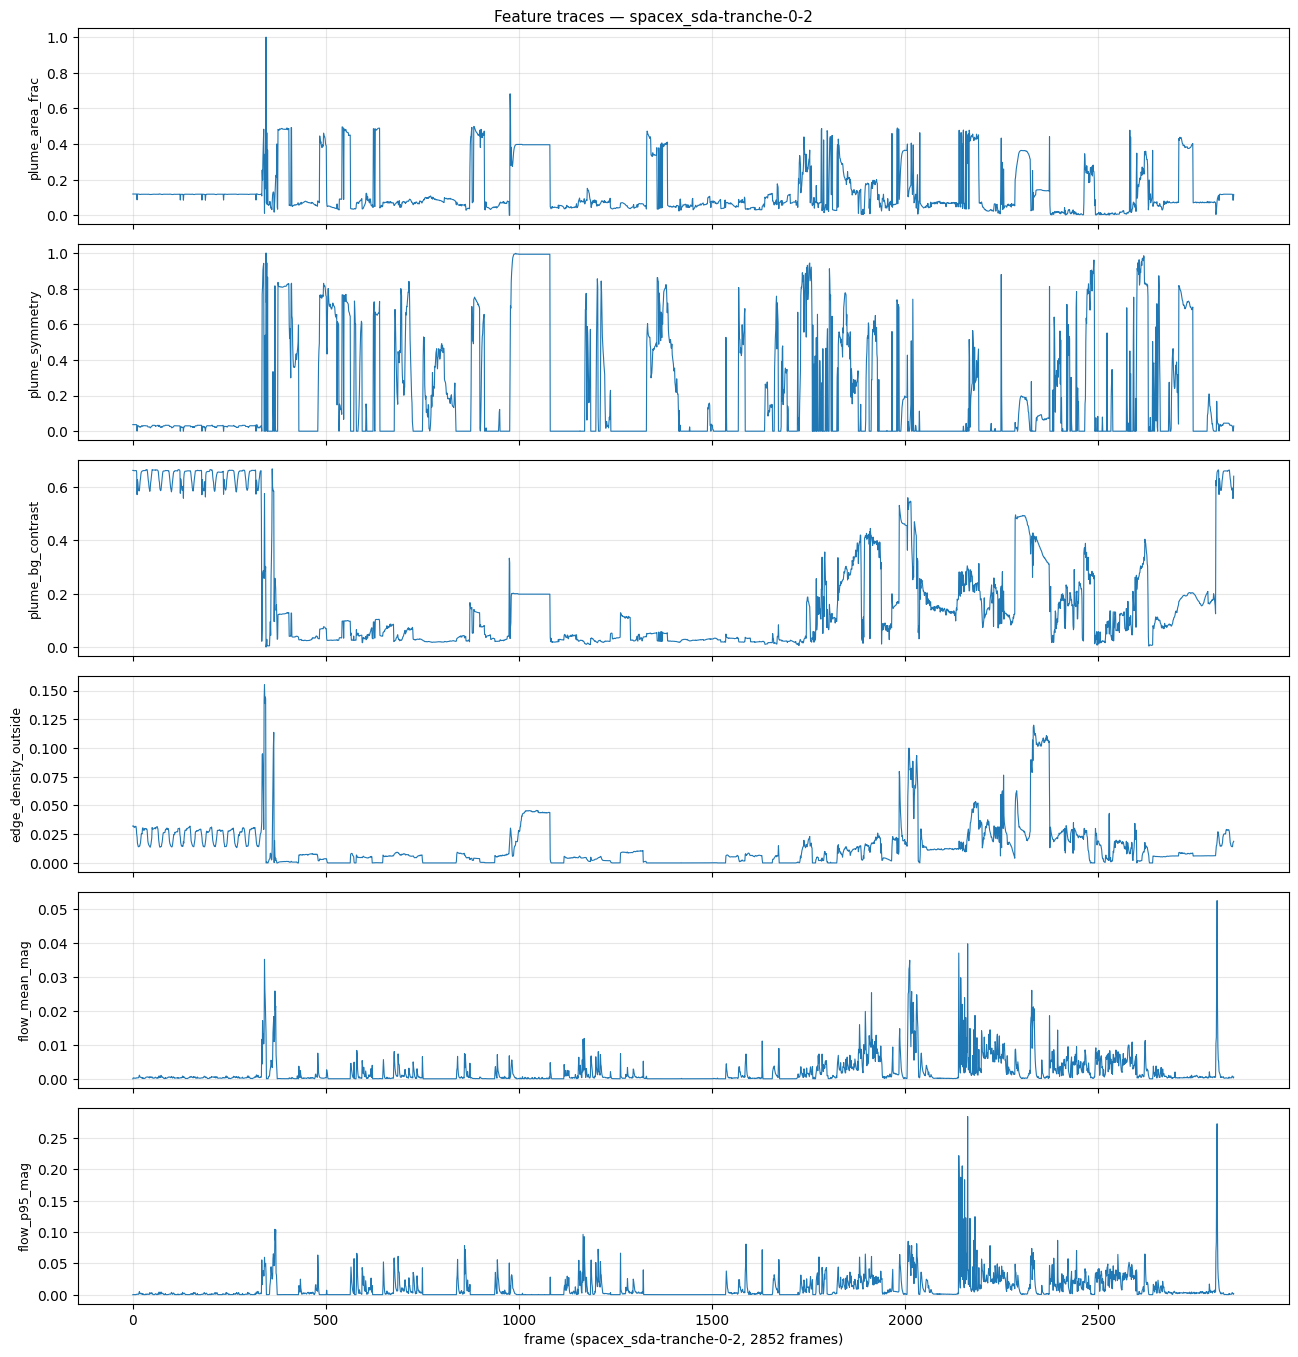

In [15]:
# --- Cell: plot a few feature traces for one video ---
import numpy as np
import matplotlib.pyplot as plt

npys = sorted(Path(FEATURES).glob('*.npy'))
video = npys[0].stem
idx = json.loads(Path(str(npys[0]).replace('.npy', '.frame_index.json')).read_text())
X = np.load(npys[0])
names = idx['feature_names']

trace_cols = ['plume_area_frac', 'plume_symmetry', 'plume_bg_contrast',
              'edge_density_outside', 'flow_mean_mag', 'flow_p95_mag']
j = {n: names.index(n) for n in trace_cols}

fig, axes = plt.subplots(len(trace_cols), 1, figsize=(13, 2.3 * len(trace_cols)),
                         sharex=True)
for ax, n in zip(axes, trace_cols):
    ax.plot(np.arange(len(X)), X[:, j[n]], lw=0.8)
    ax.set_ylabel(n, fontsize=9)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel(f'frame ({video}, {len(X)} frames)')
fig.suptitle(f'Feature traces — {video}', fontsize=11)
plt.tight_layout()
plt.show()
